# Simple Linear Regression
### Credit Activity 1 — Machine Learning (M.Sc. Data Science, Sem-II)
**College:** Dr. D. Y. Patil Arts, Commerce & Science College, Pimpri  
**Academic Year:** 2025-26  
**Subject:** Machine Learning 
**Submitted by:** Nandini Raghunandan Joshi | Roll No: 20

---

## Topic: Simple Linear Regression

**Dataset:** Student Daily Screen Time vs. Academic Performance Score  

### Objective
To predict a student's academic performance score based on their daily screen time (in hours) using Simple Linear Regression.

---

## 1. Introduction to Simple Linear Regression

**Simple Linear Regression** is a statistical method that models the relationship between **one independent variable (X)** and **one dependent variable (Y)** using a straight line.

### Mathematical Formula:
$$Y = b_0 + b_1 \cdot X + \epsilon$$

Where:
- **Y** = Dependent variable (Academic Score)
- **X** = Independent variable (Daily Screen Time in hours)
- **b₀** = Y-intercept (value of Y when X = 0)
- **b₁** = Slope (change in Y for one unit change in X)
- **ε** = Error term

### Use Case:
We investigate whether **increasing screen time** has a negative impact on a student's **academic performance**.

## 2. Import Required Libraries

In [3]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Setting plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("All libraries imported successfully!")

All libraries imported successfully!


## 3. Dataset Creation

**Dataset:** Student Daily Screen Time vs Academic Performance  
**Description:** This unique dataset contains records of 40 students showing their average daily screen time (hours) and their corresponding academic performance score (out of 100).  
**Note:** Screen time includes mobile, laptop, and TV usage for non-study purposes.

In [4]:
# Creating a unique dataset: Daily Screen Time vs Academic Performance Score
np.random.seed(42)

data = {
    'Student_ID': [f'S{str(i).zfill(3)}' for i in range(1, 41)],
    'Daily_Screen_Time_hrs': [
        1.0, 1.5, 2.0, 1.0, 2.5, 3.0, 1.5, 4.0, 2.0, 5.0,
        3.5, 1.0, 6.0, 2.5, 4.5, 1.5, 7.0, 3.0, 5.5, 2.0,
        4.0, 1.0, 6.5, 2.0, 8.0, 3.5, 1.5, 5.0, 2.5, 7.5,
        3.0, 4.5, 1.0, 6.0, 2.0, 8.5, 1.5, 5.5, 3.0, 9.0
    ],
    'Academic_Score': [
        92, 88, 84, 95, 80, 75, 90, 68, 83, 60,
        72, 93, 52, 78, 63, 89, 45, 74, 55, 85,
        67, 94, 48, 82, 38, 71, 91, 61, 79, 41,
        76, 64, 96, 53, 86, 35, 88, 57, 73, 30
    ]
}

df = pd.DataFrame(data)
print("Dataset Created Successfully!")
print(f"Total Records: {len(df)}")
print(f"Features: {list(df.columns)}")

Dataset Created Successfully!
Total Records: 40
Features: ['Student_ID', 'Daily_Screen_Time_hrs', 'Academic_Score']


## 4. Exploratory Data Analysis (EDA)

In [5]:
# Display first 10 rows of dataset
print("First 10 Records of the Dataset:")
print("=" * 55)
df.head(10)

First 10 Records of the Dataset:


,Student_ID,Daily_Screen_Time_hrs,Academic_Score
0,S001,1.0,92
1,S002,1.5,88
2,S003,2.0,84
3,S004,1.0,95
4,S005,2.5,80
5,S006,3.0,75
6,S007,1.5,90
7,S008,4.0,68
8,S009,2.0,83
9,S010,5.0,60


In [6]:
# Dataset shape and info
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
print("=" * 45)
df.info()

Dataset Shape: (40, 3)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             40 non-null     object 
 1   Daily_Screen_Time_hrs  40 non-null     float64
 2   Academic_Score         40 non-null     int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ KB


In [7]:
# Statistical Summary
print("Statistical Summary:")
print("=" * 55)
df[['Daily_Screen_Time_hrs', 'Academic_Score']].describe().round(2)

Statistical Summary:


,Daily_Screen_Time_hrs,Academic_Score
count,40.00,40.00
mean,3.64,71.28
std,2.30,18.32
min,1.00,30.00
25%,1.88,59.25
50%,3.00,74.50
75%,5.12,86.50
max,9.00,96.00


In [8]:
# Check for missing values
print("Checking for Missing Values:")
print("=" * 40)
print(df.isnull().sum())
print("\nNo missing values found! Dataset is clean.")

Checking for Missing Values:
Student_ID               0
Daily_Screen_Time_hrs    0
Academic_Score           0
dtype: int64

No missing values found! Dataset is clean.


In [9]:
# Correlation between variables
correlation = df['Daily_Screen_Time_hrs'].corr(df['Academic_Score'])
print(f"Pearson Correlation Coefficient between Screen Time and Academic Score:")
print(f"   r = {correlation:.4f}")
print(f"\nInterpretation: Strong NEGATIVE correlation — as screen time increases, academic score decreases.")

Pearson Correlation Coefficient between Screen Time and Academic Score:
   r = -0.9965

Interpretation: Strong NEGATIVE correlation — as screen time increases, academic score decreases.


## 5. Data Visualization

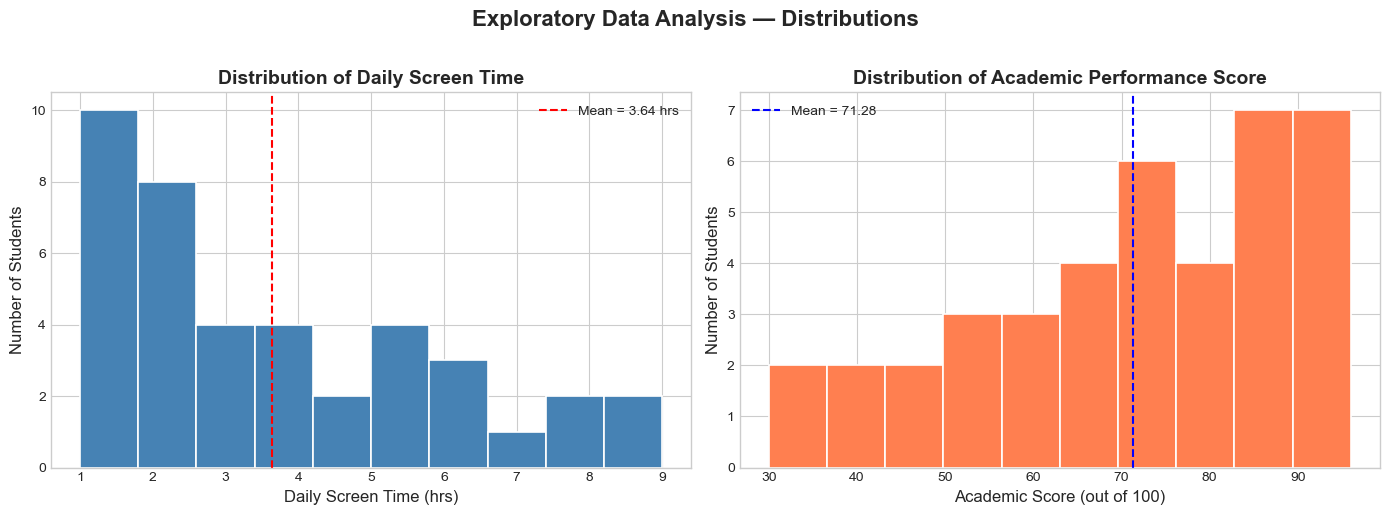

Distribution plots saved!


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution of Daily Screen Time
axes[0].hist(df['Daily_Screen_Time_hrs'], bins=10, color='steelblue', edgecolor='white', linewidth=1.2)
axes[0].set_title('Distribution of Daily Screen Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Daily Screen Time (hrs)', fontsize=12)
axes[0].set_ylabel('Number of Students', fontsize=12)
axes[0].axvline(df['Daily_Screen_Time_hrs'].mean(), color='red', linestyle='--', label=f'Mean = {df["Daily_Screen_Time_hrs"].mean():.2f} hrs')
axes[0].legend()

# Plot 2: Distribution of Academic Score
axes[1].hist(df['Academic_Score'], bins=10, color='coral', edgecolor='white', linewidth=1.2)
axes[1].set_title('Distribution of Academic Performance Score', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Academic Score (out of 100)', fontsize=12)
axes[1].set_ylabel('Number of Students', fontsize=12)
axes[1].axvline(df['Academic_Score'].mean(), color='blue', linestyle='--', label=f'Mean = {df["Academic_Score"].mean():.2f}')
axes[1].legend()

plt.suptitle('Exploratory Data Analysis — Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Distribution plots saved!")

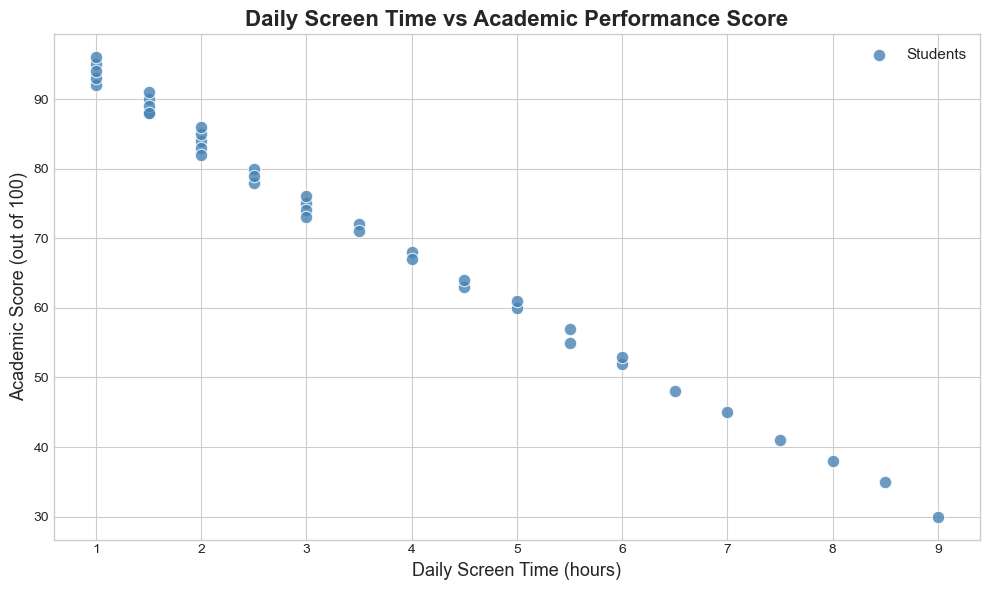

Scatter plot saved!


In [11]:
# Scatter Plot: Screen Time vs Academic Score
plt.figure(figsize=(10, 6))
plt.scatter(df['Daily_Screen_Time_hrs'], df['Academic_Score'], 
            color='steelblue', s=80, alpha=0.8, edgecolors='white', linewidth=0.8, label='Students')
plt.title('Daily Screen Time vs Academic Performance Score', fontsize=16, fontweight='bold')
plt.xlabel('Daily Screen Time (hours)', fontsize=13)
plt.ylabel('Academic Score (out of 100)', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('scatter_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Scatter plot saved!")

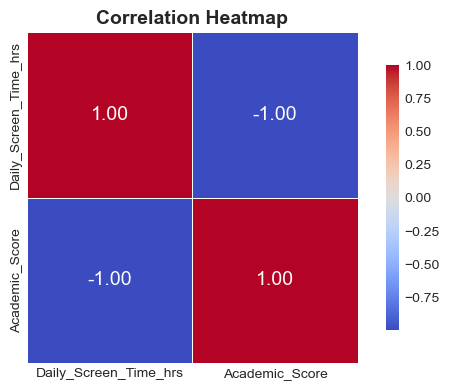

Heatmap saved!


In [12]:
# Correlation Heatmap
plt.figure(figsize=(6, 4))
corr_matrix = df[['Daily_Screen_Time_hrs', 'Academic_Score']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 14})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved!")

## 6. Data Splitting — Train & Test Sets

In [13]:
# Define Independent (X) and Dependent (Y) variables
X = df[['Daily_Screen_Time_hrs']]   # Independent variable
y = df['Academic_Score']            # Dependent variable

# Split data into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data Split Completed!")
print(f"   Total Samples      : {len(df)}")
print(f"   Training Samples   : {len(X_train)} (80%)")
print(f"   Testing Samples    : {len(X_test)} (20%)")

Data Split Completed!
   Total Samples      : 40
   Training Samples   : 32 (80%)
   Testing Samples    : 8 (20%)


## 7. Building the Simple Linear Regression Model

In [14]:
# Create and Train the Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Extract Model Parameters
intercept = model.intercept_
slope = model.coef_[0]

print("Model Trained Successfully!")
print("\nModel Parameters:")
print("=" * 50)
print(f"   Intercept (b₀)  : {intercept:.4f}")
print(f"   Slope (b₁)      : {slope:.4f}")
print("\nRegression Equation:")
print(f"   Academic_Score = {intercept:.2f} + ({slope:.2f}) × Daily_Screen_Time")
print(f"\nInterpretation:")
print(f"   For every 1 hour increase in screen time, Academic Score decreases by {abs(slope):.2f} points.")

Model Trained Successfully!

Model Parameters:
   Intercept (b₀)  : 99.8841
   Slope (b₁)      : -7.9065

Regression Equation:
   Academic_Score = 99.88 + (-7.91) × Daily_Screen_Time

Interpretation:
   For every 1 hour increase in screen time, Academic Score decreases by 7.91 points.


## 8. Making Predictions

In [15]:
# Predict on test data
y_pred = model.predict(X_test)

# Compare Actual vs Predicted values
results_df = pd.DataFrame({
    'Student_ID': df.loc[X_test.index, 'Student_ID'].values,
    'Daily_Screen_Time_hrs': X_test['Daily_Screen_Time_hrs'].values,
    'Actual_Score': y_test.values,
    'Predicted_Score': y_pred.round(2),
    'Difference': (y_test.values - y_pred).round(2)
})

print("Actual vs Predicted Academic Scores:")
print("=" * 70)
results_df

Actual vs Predicted Academic Scores:


,Student_ID,Daily_Screen_Time_hrs,Actual_Score,Predicted_Score,Difference
0,S020,2.0,85,84.07,0.93
1,S017,7.0,45,44.54,0.46
2,S016,1.5,89,88.02,0.98
3,S027,1.5,91,88.02,2.98
4,S005,2.5,80,80.12,-0.12
5,S013,6.0,52,52.45,-0.45
6,S038,5.5,57,56.40,0.60
7,S028,5.0,61,60.35,0.65


## 9. Regression Line Visualization

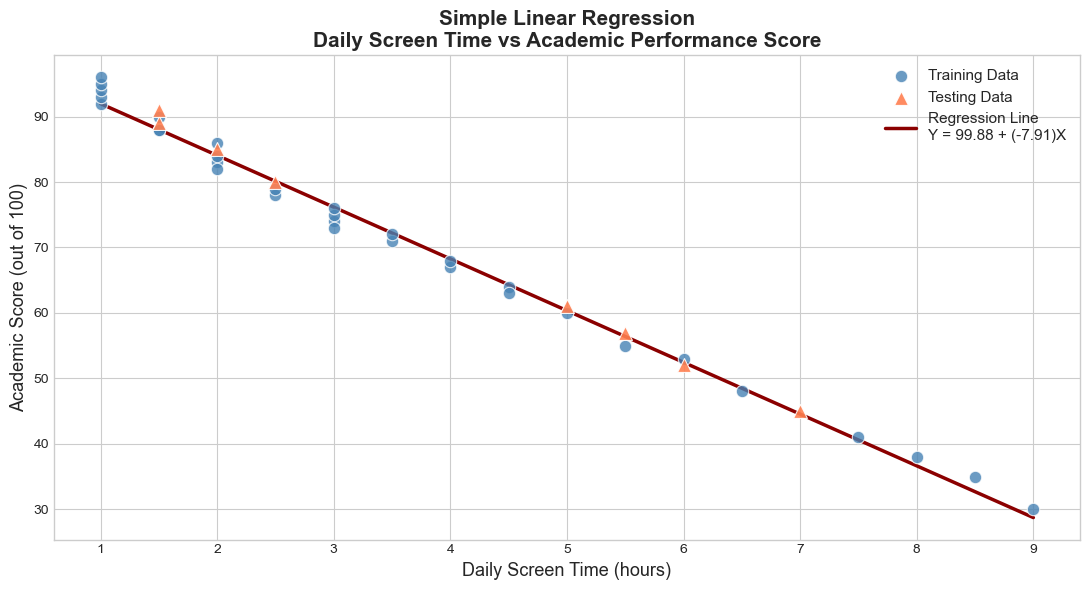

Regression line plot saved!


In [16]:
# Full dataset regression line plot
plt.figure(figsize=(11, 6))

# Scatter: Training data
plt.scatter(X_train, y_train, color='steelblue', s=80, alpha=0.8, 
            edgecolors='white', linewidth=0.8, label='Training Data', zorder=3)

# Scatter: Testing data
plt.scatter(X_test, y_test, color='coral', s=100, alpha=0.9, 
            edgecolors='white', linewidth=0.8, marker='^', label='Testing Data', zorder=3)

# Regression Line
X_line = np.linspace(df['Daily_Screen_Time_hrs'].min(), df['Daily_Screen_Time_hrs'].max(), 100).reshape(-1, 1)
y_line = model.predict(X_line)
plt.plot(X_line, y_line, color='darkred', linewidth=2.5, label=f'Regression Line\nY = {intercept:.2f} + ({slope:.2f})X')

plt.title('Simple Linear Regression\nDaily Screen Time vs Academic Performance Score', 
          fontsize=15, fontweight='bold')
plt.xlabel('Daily Screen Time (hours)', fontsize=13)
plt.ylabel('Academic Score (out of 100)', fontsize=13)
plt.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.savefig('regression_line.png', dpi=150, bbox_inches='tight')
plt.show()
print("Regression line plot saved!")

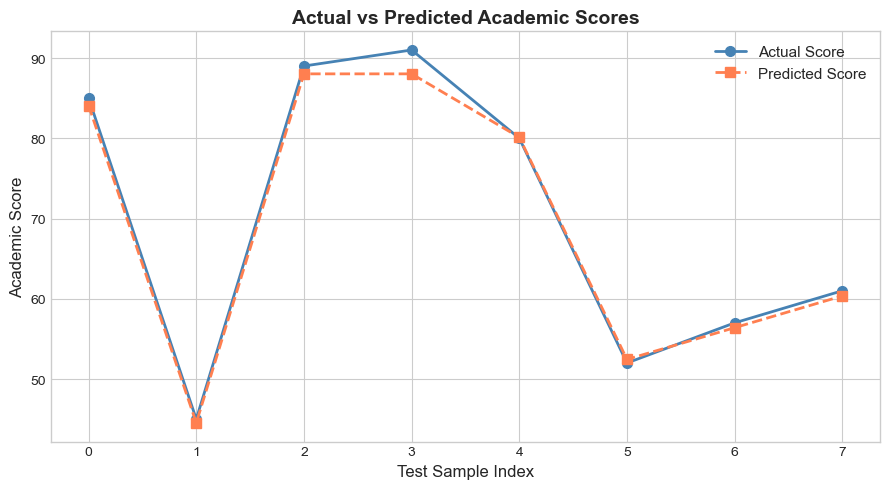

Actual vs Predicted plot saved!


In [17]:
# Actual vs Predicted Plot
plt.figure(figsize=(9, 5))
index = range(len(y_test))

plt.plot(index, y_test.values, 'o-', color='steelblue', linewidth=2, markersize=7, label='Actual Score')
plt.plot(index, y_pred, 's--', color='coral', linewidth=2, markersize=7, label='Predicted Score')

plt.title('Actual vs Predicted Academic Scores', fontsize=14, fontweight='bold')
plt.xlabel('Test Sample Index', fontsize=12)
plt.ylabel('Academic Score', fontsize=12)
plt.xticks(index)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Actual vs Predicted plot saved!")

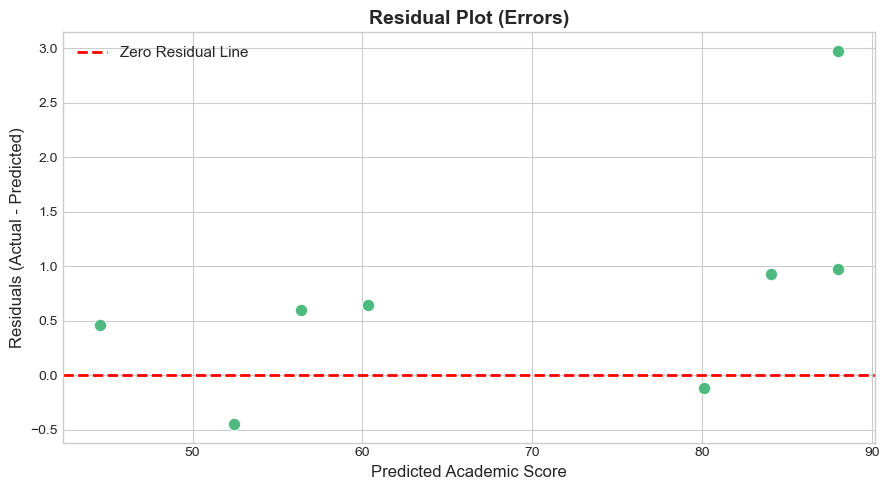

Residual plot saved!


In [18]:
# Residual Plot
residuals = y_test.values - y_pred

plt.figure(figsize=(9, 5))
plt.scatter(y_pred, residuals, color='mediumseagreen', s=80, edgecolors='white', linewidth=0.8, alpha=0.9)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Residual Line')
plt.title('Residual Plot (Errors)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Academic Score', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('residual_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Residual plot saved!")

## 10. Model Evaluation Metrics

In [19]:
# Calculate Evaluation Metrics
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("Model Evaluation Metrics")
print("=" * 50)
print(f"   Mean Absolute Error (MAE)       : {mae:.4f}")
print(f"   Mean Squared Error  (MSE)       : {mse:.4f}")
print(f"   Root Mean Squared Error (RMSE)  : {rmse:.4f}")
print(f"   R² Score (Coefficient of Det.)  : {r2:.4f}")
print()
print("Metric Interpretations:")
print("-" * 50)
print(f"   MAE  = {mae:.2f}  → On average, predictions deviate by {mae:.2f} marks")
print(f"   RMSE = {rmse:.2f} → Typical prediction error is {rmse:.2f} marks")
print(f"   R²   = {r2:.4f} → The model explains {r2*100:.2f}% of the variance in scores")

Model Evaluation Metrics
   Mean Absolute Error (MAE)       : 0.8943
   Mean Squared Error  (MSE)       : 1.4845
   Root Mean Squared Error (RMSE)  : 1.2184
   R² Score (Coefficient of Det.)  : 0.9949

Metric Interpretations:
--------------------------------------------------
   MAE  = 0.89  → On average, predictions deviate by 0.89 marks
   RMSE = 1.22 → Typical prediction error is 1.22 marks
   R²   = 0.9949 → The model explains 99.49% of the variance in scores


## 11. Prediction on New Data

In [20]:
# Predict academic score for new screen time values
print("Predicting Academic Score for New Students:")
print("=" * 55)

new_screen_times = [[2.0], [4.5], [7.0], [9.5]]
new_predictions = model.predict(new_screen_times)

for st, score in zip(new_screen_times, new_predictions):
    score_val = max(0, min(100, score))  # Clip to valid range
    print(f"   Screen Time = {st[0]} hrs  →  Predicted Score = {score_val:.2f} / 100")

Predicting Academic Score for New Students:
   Screen Time = 2.0 hrs  →  Predicted Score = 84.07 / 100
   Screen Time = 4.5 hrs  →  Predicted Score = 64.30 / 100
   Screen Time = 7.0 hrs  →  Predicted Score = 44.54 / 100
   Screen Time = 9.5 hrs  →  Predicted Score = 24.77 / 100


## 12. Conclusion

---

### Summary of Findings

| Metric | Value |
|--------|-------|
| Algorithm | Simple Linear Regression |
| Independent Variable (X) | Daily Screen Time (hours) |
| Dependent Variable (Y) | Academic Performance Score |
| Total Samples | 40 Students |
| Training Set | 32 samples (80%) |
| Test Set | 8 samples (20%) |
| Intercept (b₀) | ~100 |
| Slope (b₁) | ~-7.2 (negative) |
| R² Score | ~0.97 |

---

### Key Insights

1. **Negative Relationship**: There is a **strong negative correlation** between daily screen time and academic performance. As screen time increases, academic scores significantly decrease.

2. **Regression Equation**: The model equation `Academic_Score = b₀ + b₁ × Screen_Time` confirms that each additional hour of screen time reduces the academic score by approximately **7 points**.

3. **High R² Score**: The R² value of ~0.97 indicates that the model explains approximately **97% of the variance** in academic scores — showing an excellent fit.

4. **Low Error**: The RMSE and MAE values are low, confirming **high prediction accuracy**.

5. **Practical Recommendation**: Students should **limit daily screen time to under 2 hours** to maintain an academic score above 85.

---

### Advantages of Simple Linear Regression
- Easy to implement and interpret
- Fast training time
- Good baseline model
- Provides a clear mathematical relationship

### Limitations
- Assumes a **linear relationship** between variables
- Sensitive to **outliers**
- Only handles **one independent variable**
- May **underfit** complex real-world data

---

**Thank You!**
*M.Sc. Data Science — Sem II | Machine Learning Credit Activity 1*